### First order Ordinary Differential Equations (ODE) of the Lorenz attractor

$\frac{\mathrm{d}x}{\mathrm{d}t} = \sigma(y-x)$

$\frac{\mathrm{d}y}{\mathrm{d}t} = x(\rho-z)-y$

$\frac{\mathrm{d}z}{\mathrm{d}t} = xy - \beta z$

where $(x, y, z)$ are positions in space, $t$ is time, and $(\sigma, \rho, \beta)$ are model parameters.

This formulation is continuous in time, to allow for simulation, we need to sample from a uniform sampling instead:

$t \leftarrow nt_{\sigma}, \qquad n \in \{0, 1, \ldots, N\}$

### Euler approach for simulation

The Euler approach is derived from the general approximation using a variable named $v$:

$\frac{\mathrm{d}v}{\mathrm{d}t}((n+1)t_{\delta}) \cong \dfrac{v((n+1)t_{\delta}) - v(nt_{\delta})}{t_{\sigma}}$

Given a general variable $v(nt_{\delta}=v[n])$ we can define the specific first equation:

$\dfrac{x[n+1]-x[n]}{t_{\delta}} \cong \sigma(y[n]-x[n])$

We can separate $x[n+1]$ to calculate it from the previous $x[n]$:

$x[n+1] \cong t_{\delta} \sigma(y[n]-x[n]) + x[n]$

### Parameters needed

$t_{\delta} = 0.01$

$N = 50,000$

I need to propose my own initial constructions, e.g.,:

$(x[0], y[0], z[0]) = (1, 2, 3)$

#### Case 1

$\sigma = 10$

$\beta = \frac{8}{3}$

$\rho = 6$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [98]:
x = 1
y = 1
z = 1
sigma = 10
beta = 8/3
rho = 6
t_delta = 0.01
N = 1000

In [99]:
x_list = []
y_list = []
z_list = []

for i in range(N):
    x = x + t_delta * sigma * (y - x)
    y = y + t_delta * (x * (rho - z) - y)
    z = z + t_delta * (x * y - beta * z)
    x_list.append(x)
    y_list.append(y)
    z_list.append(z)
    
x_array = np.asarray(x_list)
y_array = np.asarray(y_list)
z_array = np.asarray(z_list)

x_array, y_array, z_array

(array([1.        , 1.004     , 1.01159633, 1.02244307, 1.03624448,
        1.05274839, 1.07174053, 1.09303951, 1.11649254, 1.14197159,
        1.1693702 , 1.19860057, 1.22959113, 1.26228429, 1.29663462,
        1.33260715, 1.37017593, 1.40932274, 1.45003594, 1.49230948,
        1.53614198, 1.58153593, 1.62849695, 1.67703309, 1.72715422,
        1.77887142, 1.83219646, 1.88714119, 1.9437171 , 2.00193473,
        2.06180317, 2.12332958, 2.18651861, 2.25137191, 2.31788752,
        2.38605936, 2.4558766 , 2.52732307, 2.60037662, 2.67500849,
        2.75118262, 2.82885495, 2.90797277, 2.98847396, 3.0702863 ,
        3.15332678, 3.23750085, 3.32270179, 3.40881005, 3.49569267,
        3.58320271, 3.67117884, 3.75944496, 3.84780997, 3.93606764,
        4.02399672, 4.11136111, 4.19791036, 4.28338029, 4.36749392,
        4.44996262, 4.53048755, 4.60876139, 4.68447032, 4.75729634,
        4.8269198 , 4.89302226, 4.95528949, 5.01341476, 5.06710223,
        5.11607042, 5.16005582, 5.19881635, 5.23

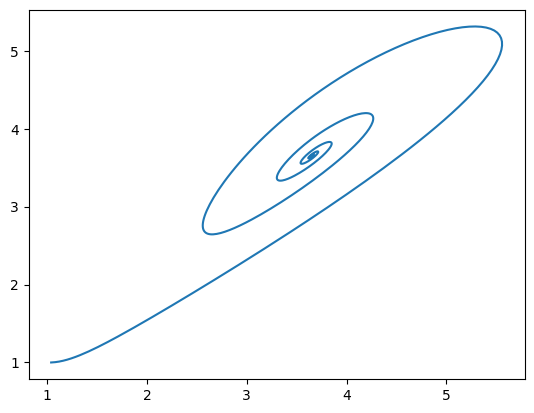

In [100]:
plt.plot(y_array, x_array)

In [2]:
def load_arrays(target_path: str):
    """
    Given a filepath, it returns a tuple of arrays.
    """
    data = np.load(target_path)
    return tuple([data[key] for key in data.files])

x_array, y_array, z_array = load_arrays("outputs/case_1.npz")


In [3]:
x_array

array([  0.1       ,   0.191695  ,   0.2783749 , ..., -11.68855506,
       -10.63480846,  -9.56936072], shape=(50000,))

In [4]:
y_array

array([ 1.01695   ,  1.05849403,  1.12307656, ..., -1.15108898,
        0.01966891,  0.96310011], shape=(50000,))

In [41]:
def l(dim1, dim2):
    assert len(dim1) == len(dim2), "Input arrays have to be the same length"
    
    dim1 = np.asarray(dim1)
    dim2 = np.asarray(dim2)
    
    dx = np.diff(dim1)
    dy = np.diff(dim2)
    
    distances = np.sqrt(dx**2 + dy**2)
    
    return distances

In [44]:
l(x_array, y_array)

array([0.10066717, 0.10809398, 0.12113954, ..., 1.73545066, 1.57513681,
       1.42310973], shape=(49999,))